# Workshop: Tunix-Med · Part 3: Supervised Fine-Tuning with JAX & Tunix

This is the core of the workshop. We use **Tunix**, a high-performance JAX-based fine-tuning library, to train the **Gemma 3 1B** model on our cardiology dataset.

### Why JAX and Tunix?
1. **XLA Compilation**: JAX uses the XLA compiler to fuse operations into highly efficient kernels.
2. **Streaming Data**: A pipeline that never loads the whole dataset into RAM.
3. **Advanced LoRA**: Low-Rank Adaptation applied to both Linear *and* Einsum layers in Gemma 3's attention.


## 1 · Environment & JAX Setup

In [1]:
import os
import logging

# Prevent JAX from hogging all VRAM immediately
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Silence verbose library logging for a cleaner workshop experience
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
for _name in ("absl", "jax", "orbax", "flax", "datasets", "transformers", "grain"):
    logging.getLogger(_name).setLevel(logging.ERROR)

import jax
import jax.numpy as jnp
import numpy as np

print(f"JAX backend : {jax.default_backend()}")
print(f"Devices     : {jax.devices()}")

JAX backend : gpu
Devices     : [CudaDevice(id=0)]


## 2 · Hyperparameter Configuration

`MAX_STEPS` is computed **after** the dataset split is created (Cell 4), because it
depends on the number of training examples.  All other hyper-parameters live here.


In [2]:
class Config:
    MODEL_NAME = "google/gemma-3-270M-it"
    MODEL_KEY = "gemma-3-270M-it"
    TUNED_MODEL_NAME = f"lmassaron/{MODEL_KEY}-medical-cardiology-lora"

    DATASET_PATH = "data/medical-cardiology-qa"
    MAX_SEQ_LEN = 1024
    EVAL_SPLIT = 0.1
    SEED = 42

    # LoRA 
    LORA_RANK = 32
    LORA_ALPHA = 32
    LORA_DROPOUT = 0.05

    # Optimisation
    LEARNING_RATE = 5e-5
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1

    # Training loop
    BATCH_SIZE = 8
    GRAD_ACCUM_STEPS = 4
    NUM_EPOCHS = 24
    EARLY_STOP_PATIENCE = 5
    EVAL_EVERY_N_STEPS = 100
    LOG_EVERY_N_STEPS = 100
    OUTPUT_DIR = "tunix-medical-model"

    # Computed after the dataset is loaded
    MAX_STEPS: int = 0


params = Config()
print(f"Effective Batch Size: {params.BATCH_SIZE * params.GRAD_ACCUM_STEPS}")

Effective Batch Size: 32


## 3 · Streaming Data Pipeline

In [4]:
import datasets
from datasets import load_dataset
from transformers import AutoTokenizer
from tunix.sft import peft_trainer

hf_tokenizer = AutoTokenizer.from_pretrained(params.MODEL_NAME)
full_ds = load_dataset("lmassaron/medical-cardiology-qa", split="train")
n = len(full_ds)

# Reproducible train / eval split
rng = np.random.default_rng(params.SEED)
all_idx = rng.permutation(n)
cut = int(n * (1.0 - params.EVAL_SPLIT))
train_idx, eval_idx = all_idx[:cut], all_idx[cut:]

# ── Compute MAX_STEPS now that we know the dataset size ──────────────────────
_steps_per_epoch = len(train_idx) // params.BATCH_SIZE
params.MAX_STEPS = (_steps_per_epoch * params.NUM_EPOCHS) // params.GRAD_ACCUM_STEPS
print(f"Dataset    : {n:,} rows  |  Train: {len(train_idx):,}  Eval: {len(eval_idx):,}")
print(
    f"MAX_STEPS  : {params.MAX_STEPS}  (warmup: {int(params.MAX_STEPS * params.WARMUP_RATIO)})"
)

Dataset    : 10,518 rows  |  Train: 9,466  Eval: 1,052
MAX_STEPS  : 7098  (warmup: 709)


In [5]:
def _tokenise(example):
    messages = example["messages"]
    full_ids = hf_tokenizer.apply_chat_template(messages, tokenize=True)
    prompt_ids = hf_tokenizer.apply_chat_template(
        messages[:-1], tokenize=True, add_generation_prompt=True
    )
    # Extract IDs if it's a BatchEncoding
    if hasattr(full_ids, "input_ids"):
        full_ids = full_ids["input_ids"]
    if hasattr(prompt_ids, "input_ids"):
        prompt_ids = prompt_ids["input_ids"]

    prompt_len = len(prompt_ids)
    full_ids = full_ids[: params.MAX_SEQ_LEN]

    mask = np.ones(len(full_ids), dtype=np.int32)
    mask[: min(prompt_len, len(full_ids))] = 0

    pad_len = params.MAX_SEQ_LEN - len(full_ids)
    tokens = np.pad(
        full_ids, (0, pad_len), constant_values=hf_tokenizer.pad_token_id
    ).astype(np.int32)
    mask = np.pad(mask, (0, pad_len), constant_values=0).astype(np.int32)
    return {"input_tokens": tokens, "input_mask": mask}


def make_data_iterator(dataset, indices, batch_size, shuffle=True, infinite=True):
    while True:
        idxs = indices.copy()
        if shuffle:
            np.random.shuffle(idxs)
        for start in range(0, len(idxs) - batch_size + 1, batch_size):
            batch_idx = idxs[start : start + batch_size]
            processed = [_tokenise(dataset[int(i)]) for i in batch_idx]
            tokens = np.stack([p["input_tokens"] for p in processed])
            masks = np.stack([p["input_mask"] for p in processed])
            yield peft_trainer.TrainingInput(
                input_tokens=jnp.array(tokens),
                input_mask=jnp.array(masks),
            )
        if not infinite:
            break


train_iter = make_data_iterator(full_ds, train_idx, params.BATCH_SIZE)
print("Streaming data pipeline configured.")

Streaming data pipeline configured.


## 4 · Model & Custom LoRA Setup

Gemma 3 uses **Einsum** operations for its attention.  We provide custom LoRA layers to support both Linear and Einsum modules.


In [6]:
from flax import nnx
from tunix.models import automodel
from huggingface_hub import snapshot_download

# Build model on a 1-D mesh (single-GPU or single-TPU)
devices = np.array(jax.devices()).reshape((1, -1))
mesh = jax.sharding.Mesh(devices, axis_names=("tp", "fsdp"))
model_path = snapshot_download(params.MODEL_NAME)
model_config = automodel.call_model_config(params.MODEL_KEY)

with mesh:
    model = automodel.create_model_from_safe_tensors(
        params.MODEL_KEY, model_path, model_config, mesh, dtype=jnp.bfloat16
    )

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

In [7]:
# ── Custom LoRA wrappers for Linear and Einsum layers ────────────────────────
class LinearLoRALayer(nnx.Module):
    def __init__(
        self, linear_module, rank, alpha, dropout, dtype=jnp.bfloat16, rngs=None
    ):
        self.linear = linear_module
        self.rank = rank
        self.scale = alpha / rank
        self.dropout = nnx.Dropout(dropout, rngs=rngs)

        in_features = linear_module.in_features
        out_features = linear_module.out_features

        self.lora_a = nnx.LoRAParam(
            jax.random.normal(rngs.params(), (in_features, rank), dtype=dtype) * 0.01
        )
        self.lora_b = nnx.LoRAParam(jnp.zeros((rank, out_features), dtype=dtype))

    def __call__(self, x):
        base = self.linear(x)
        lora = (self.dropout(x) @ self.lora_a[...] @ self.lora_b[...]) * self.scale
        return base + lora.astype(x.dtype)


class EinsumLoRALayer(nnx.Module):
    def __init__(
        self, einsum_module, rank, alpha, dropout, dtype=jnp.bfloat16, rngs=None
    ):
        self.einsum = einsum_module
        self.rank = rank
        self.scale = alpha / rank
        self.dropout = nnx.Dropout(dropout, rngs=rngs)

        w = einsum_module.w
        in_dim = int(np.prod(w.shape[:-1]))
        out_dim = w.shape[-1]

        self.lora_a = nnx.LoRAParam(
            jax.random.normal(rngs.params(), (in_dim, rank), dtype=dtype) * 0.01
        )
        self.lora_b = nnx.LoRAParam(jnp.zeros((rank, out_dim), dtype=dtype))

    def __call__(self, x):
        base = self.einsum(x)
        delta_w = (self.lora_a[...] @ self.lora_b[...]).reshape(self.einsum.w.shape)
        return base + self.scale * jnp.einsum(
            self.einsum.einsum_str, self.dropout(x), delta_w.astype(x.dtype)
        )


def _get_child(parent, key):
    try:
        return getattr(parent, str(key))
    except AttributeError:
        return parent[int(key)]


def _set_child(parent, key, value):
    try:
        setattr(parent, str(key), value)
    except (AttributeError, TypeError):
        parent[int(key)] = value


def apply_lora(model, rank, alpha, dropout):
    replaced = 0
    rngs = nnx.Rngs(params=0, dropout=0)
    for path, mod in nnx.graph.iter_graph(model):
        if not path:
            continue
        parent = model
        try:
            for step in path[:-1]:
                parent = _get_child(parent, step)
            attr = path[-1]
        except Exception:
            continue

        if isinstance(mod, nnx.Linear):
            _set_child(
                parent, attr, LinearLoRALayer(mod, rank, alpha, dropout, rngs=rngs)
            )
            replaced += 1
        elif isinstance(mod, nnx.Einsum):
            _set_child(
                parent, attr, EinsumLoRALayer(mod, rank, alpha, dropout, rngs=rngs)
            )
            replaced += 1
    return replaced


with mesh:
    n_lora = apply_lora(model, params.LORA_RANK, params.LORA_ALPHA, params.LORA_DROPOUT)
print(f"Patched {n_lora} layers with LoRA.")

Patched 54 layers with LoRA.


## 5 · Training Hooks & Export Logic

The `CleanProgressHook` logs **loss, perplexity** (`exp(loss)`, matching what tunix computes internally in its MetricsLogger) and **gradient norm** at every log step.

> **How gradient norm is captured:** tunix's `on_train_step_end` hook only receives `(train_ctx, step, loss, step_time)` — gradient norm is not part of the hook API. We inject a custom stateless `optax` transform (`capture_grad_norm`) *before* the AdamW optimizer. Inside the JIT-compiled train step it calls `jax.experimental.io_callback` to write the pre-clip norm to a Python list, which the hook then reads at each log step.

In [8]:
import math
import optax
import time
import jax
import jax.numpy as jnp
from tunix.sft import hooks

def export_adapter(model, cfg):
    import os, json, safetensors.flax as stf
    from flax import nnx

    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    config = {
        "base_model_name_or_path": cfg.MODEL_NAME,
        "lora_alpha": cfg.LORA_ALPHA,
        "lora_dropout": cfg.LORA_DROPOUT,
        "r": cfg.LORA_RANK,
        "target_modules": [
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
        "peft_type": "LORA",
        "task_type": "CAUSAL_LM",
        "bias": "none",
    }
    with open(os.path.join(cfg.OUTPUT_DIR, "adapter_config.json"), "w") as f:
        json.dump(config, f, indent=2)

    lora_weights = {}
    from flax import nnx as _nnx
    for path, leaf in _nnx.graph.iter_graph(model):
        if not isinstance(leaf, (_nnx.Param, _nnx.LoRAParam)):
            continue
        key = ".".join(str(p) for p in path)
        if "lora" not in key.lower():
            continue
        peft_key = "base_model.model.model." + key
        peft_key = (
            peft_key.replace(".lora_a", ".lora_A.weight")
                    .replace(".lora_b", ".lora_B.weight")
                    .replace(".value", "")
        )
        lora_weights[peft_key] = leaf[...].T  # JAX(in,rank)->(rank,in) / (rank,out)->(out,rank) for PEFT

    if lora_weights:
        stf.save_file(
            lora_weights,
            os.path.join(cfg.OUTPUT_DIR, "adapter_model.safetensors"),
        )
        print(f"  Adapter saved → {cfg.OUTPUT_DIR}/adapter_model.safetensors")

In [9]:
# ── Gradient-norm capture via a custom optax transform ───────────────────────
# tunix's on_train_step_end hook receives (train_ctx, step, loss, step_time)
# and does NOT expose gradient norm.  We inject a stateless optax transform
# that runs *inside* the JIT-compiled step and writes the pre-clip global norm
# to a Python list via jax.experimental.io_callback.

_grad_norm_capture: list[float] = []  # written inside JIT, read in hook

def _store_norm(norm_scalar: jnp.ndarray) -> None:
    """Python callback: appends the gradient norm captured from inside JIT."""
    _grad_norm_capture.append(float(norm_scalar))


def capture_grad_norm() -> optax.GradientTransformation:
    """
    A stateless optax transform that records the global gradient norm
    (BEFORE any clipping) via jax.experimental.io_callback.

    Place this transform first in an optax.chain() so it sees raw gradients.
    Because tunix wraps the user-supplied optimizer with optax.MultiSteps
    internally, this callback fires once per actual weight update (i.e. every
    GRAD_ACCUM_STEPS micro-batches), which is exactly the right cadence to
    match on_train_step_end.
    """

    def init_fn(params):
        return optax.EmptyState()

    def update_fn(updates, state, params=None):
        norm = optax.global_norm(updates)
        # ordered=True ensures the Python side sees one norm per train step
        jax.experimental.io_callback(_store_norm, None, norm, ordered=True)
        return updates, state

    return optax.GradientTransformation(init_fn, update_fn)

In [ ]:
# ── CleanProgressHook ─────────────────────────────────────────────────────────
class CleanProgressHook(hooks.TrainingHooks):
    """
    Logs loss, perplexity, and gradient norm at every log step.
    Saves the best adapter only when eval loss actually improves (from OLD).
    Raises StopIteration for early stopping.

    Perplexity: tunix already computes exp(loss) internally in its MetricsLogger;
    we mirror that here so it appears in stdout too.

    Gradient norm: read from _grad_norm_capture after each train step.
    """

    def __init__(
        self,
        log_every,
        max_steps,
        steps_per_epoch,
        eval_idx_ref,
        model,
        params,
        export_fn,
        patience=5,
    ):
        self._log_every = log_every
        self._max_steps = max_steps
        self._steps_per_epoch = max(1, steps_per_epoch)
        self._eval_idx = eval_idx_ref
        self._model = model
        self._params = params
        self._export_fn = export_fn
        self._patience = patience
        self._best_loss = float("inf")
        self._no_improve = 0
        self._t0 = time.time()
        self._step = 0
        # History lists for post-training plots
        self.train_loss_history = []  # [(step, loss), ...]
        self.eval_loss_history = []  # [(step, loss), ...]
        self.grad_norm_history = []  # [(step, grad_norm), ...]

    def on_train_start(self, train_ctx):
        pass

    def on_train_end(self, train_ctx):
        pass

    def on_train_step_start(self, train_ctx):
        pass

    def on_eval_step_start(self, train_ctx):
        pass

    def on_train_step_end(self, train_ctx, train_step, train_loss, step_time):
        # tunix hook API: (train_ctx, step, loss, step_time) — no grad_norm arg
        self._step = train_step
        loss_val = float(train_loss)
        ppl = math.exp(min(loss_val, 20.0))  # cap to avoid inf

        self.train_loss_history.append((self._step, loss_val))

        # Read gradient norm captured by the optax transform (if available)
        if _grad_norm_capture:
            grad_norm = _grad_norm_capture[-1]
            _grad_norm_capture.clear()
            self.grad_norm_history.append((self._step, grad_norm))
        else:
            grad_norm = None

        if self._step % self._log_every == 0:
            epoch = self._step / self._steps_per_epoch
            elapsed = time.time() - self._t0
            gn_str = f"  grad_norm={grad_norm:.4f}" if grad_norm is not None else ""
            print(
                f"  step {self._step:>5}/{self._max_steps}"
                f"  epoch={epoch:.2f}"
                f"  loss={loss_val:.4f}"
                f"  ppl={ppl:.2f}"
                f"{gn_str}"
                f"  elapsed={elapsed:.0f}s"
            )

    def on_eval_step_end(self, train_ctx, eval_loss):
        n_complete_batches = max(1, len(self._eval_idx) // self._params.BATCH_SIZE)
        mean_loss  = float(eval_loss) / n_complete_batches
        mean_ppl   = math.exp(min(mean_loss, 20.0))   # exp(mean_loss), NOT mean(exp(loss_i))
        self.eval_loss_history.append((self._step, mean_loss))

        if mean_loss < self._best_loss:
            self._best_loss = mean_loss
            self._no_improve = 0
            self._export_fn(self._model, self._params)
            print(
                f"  [eval] step {self._step}"
                f"  loss={mean_loss:.4f}  ppl={mean_ppl:.2f} ↓ — Adapter saved!"
            )
        else:
            self._no_improve += 1
            print(
                f"  [eval] step {self._step}"
                f"  loss={mean_loss:.4f}  ppl={mean_ppl:.2f}"
                f"  (Best: {self._best_loss:.4f})"
                f"  No improvement {self._no_improve}/{self._patience}"
            )
            if self._no_improve >= self._patience:
                raise StopIteration

In [11]:
# ── Scheduler & Optimizer ────────────────────────────────────────────────────
schedule = optax.warmup_cosine_decay_schedule(
    0.0,
    params.LEARNING_RATE,
    int(params.MAX_STEPS * params.WARMUP_RATIO),
    params.MAX_STEPS,
)

# capture_grad_norm() MUST come first so it sees raw (un-clipped) gradients.
# clip_by_global_norm(1.0) is good practice to keep training stable.
optimizer = optax.chain(
    capture_grad_norm(),  # ← records pre-clip global norm
    optax.clip_by_global_norm(1.0),  # ← standard gradient clipping
    optax.adamw(
        learning_rate=schedule,
        weight_decay=params.WEIGHT_DECAY,
    ),
)

In [12]:
# ── Hook ─────────────────────────────────────────────────────────────────────
_steps_per_epoch = len(train_idx) // params.BATCH_SIZE

hook = CleanProgressHook(
    log_every=params.LOG_EVERY_N_STEPS,
    max_steps=params.MAX_STEPS,
    steps_per_epoch=_steps_per_epoch,
    eval_idx_ref=eval_idx,
    model=model,
    params=params,
    export_fn=export_adapter,
    patience=params.EARLY_STOP_PATIENCE,
)


def gen_model_input(training_input):
    from tunix.sft import utils as sft_utils

    tokens = training_input.input_tokens
    mask = training_input.input_mask
    positions = sft_utils.build_positions_from_mask(mask)
    attention_mask = sft_utils.make_causal_attn_mask(mask)
    return {
        "input_tokens": tokens,
        "input_mask": mask,
        "positions": positions,
        "attention_mask": attention_mask,
    }


trainer = peft_trainer.PeftTrainer(
    model,
    optimizer,
    peft_trainer.TrainingConfig(
        max_steps=params.MAX_STEPS,
        eval_every_n_steps=params.EVAL_EVERY_N_STEPS,
        gradient_accumulation_steps=params.GRAD_ACCUM_STEPS,
    ),
)
trainer.with_training_hooks(hook)
trainer.with_gen_model_input_fn(gen_model_input)
print("Trainer ready.")

Trainer ready.


## 6 · Execute Training

In [13]:
class ReusableEvalIter:
    def __iter__(self):
        return make_data_iterator(
            full_ds, eval_idx, params.BATCH_SIZE, shuffle=False, infinite=False
        )


with mesh:
    try:
        trainer.train(train_iter, ReusableEvalIter())
    except StopIteration:
        print("Early stopping triggered.")
    except Exception as e:
        import traceback

        traceback.print_exc()
        raise

print(f"Training complete. Best adapter saved in: {params.OUTPUT_DIR}")

  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 0  loss=11.5177  ppl=100478.80 ↓ — Adapter saved!


Training:   0%|          | 0/7098 [00:00<?, ?step/s]

  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 99  loss=8.9029  ppl=7353.33 ↓ — Adapter saved!
  step   100/7098  epoch=0.08  loss=9.1044  ppl=8994.79  grad_norm=27.7500  elapsed=450s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 199  loss=5.1427  ppl=171.17 ↓ — Adapter saved!
  step   200/7098  epoch=0.17  loss=5.0784  ppl=160.51  grad_norm=4.1562  elapsed=647s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 299  loss=3.8946  ppl=49.13 ↓ — Adapter saved!
  step   300/7098  epoch=0.25  loss=3.5911  ppl=36.27  grad_norm=2.6719  elapsed=845s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 399  loss=3.4219  ppl=30.63 ↓ — Adapter saved!
  step   400/7098  epoch=0.34  loss=3.5198  ppl=33.78  grad_norm=2.4531  elapsed=1042s
  Adapter saved → tunix-medical-model/adapter_model.safetensors
  [eval] step 499  loss=2.9350  ppl=18.82 ↓ — Adapter saved!
  step   500/7098  epoch

## 7 · Training Curves

Two-panel matplotlib figure: **(left)** train and validation loss over gradient-update steps; **(right)** gradient norm (if the tunix training context exposes it — the panel is skipped gracefully otherwise).

In [14]:
def downsample(x, y, k=10):
    return x[::k], y[::k]

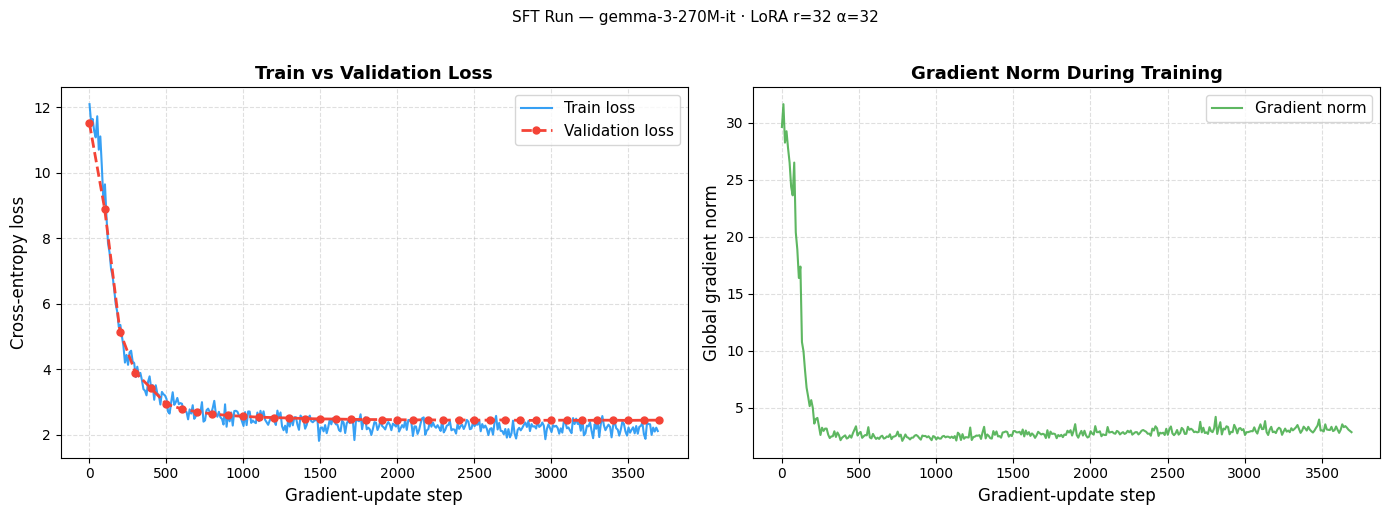

Figure saved → training_curves.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

train_steps, train_losses = (
    zip(*hook.train_loss_history) if hook.train_loss_history else ([], [])
)
eval_steps, eval_losses = (
    zip(*hook.eval_loss_history) if hook.eval_loss_history else ([], [])
)
gn_steps, gn_vals = zip(*hook.grad_norm_history) if hook.grad_norm_history else ([], [])

has_grad_norm = len(gn_steps) > 0
n_panels = 2 if has_grad_norm else 1

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

# ── Panel 1 · Loss ────────────────────────────────────────────────────────────
train_steps_ds, train_losses_ds = downsample(train_steps, train_losses, k=10)
eval_steps_ds, eval_losses_ds = downsample(eval_steps, eval_losses, k=1)  # keep eval dense

ax = axes[0]
if train_losses:
    ax.plot(
        train_steps_ds,
        train_losses_ds,
        label="Train loss",
        color="#2196F3",
        lw=1.5,
        alpha=0.9,
    )
if eval_losses:
    ax.plot(
        eval_steps_ds,
        eval_losses_ds,
        label="Validation loss",
        color="#F44336",
        lw=2,
        linestyle="--",
        marker="o",
        markersize=5,
    )

ax.set_xlabel("Gradient-update step", fontsize=12)
ax.set_ylabel("Cross-entropy loss", fontsize=12)
ax.set_title("Train vs Validation Loss", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ── Panel 2 · Gradient Norm (if available) ───────────────────────────────────
if has_grad_norm:
    gn_steps_ds, gn_vals_ds = downsample(gn_steps, gn_vals, k=10)
    ax2 = axes[1]
    ax2.plot(
        gn_steps_ds, gn_vals_ds, color="#4CAF50", lw=1.5, alpha=0.9, label="Gradient norm"
    )
    ax2.set_xlabel("Gradient-update step", fontsize=12)
    ax2.set_ylabel("Global gradient norm", fontsize=12)
    ax2.set_title("Gradient Norm During Training", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
else:
    print(
        "ℹ️  Gradient norm was not exposed by the tunix training context "
        "(hook.grad_norm_history is empty).\n"
        "   The right panel has been omitted. To enable it, ensure your "
        "tunix version sets train_ctx.grad_norm during the training step."
    )

plt.suptitle(
    f"SFT Run — {params.MODEL_KEY} · LoRA r={params.LORA_RANK} α={params.LORA_ALPHA}",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → training_curves.png")

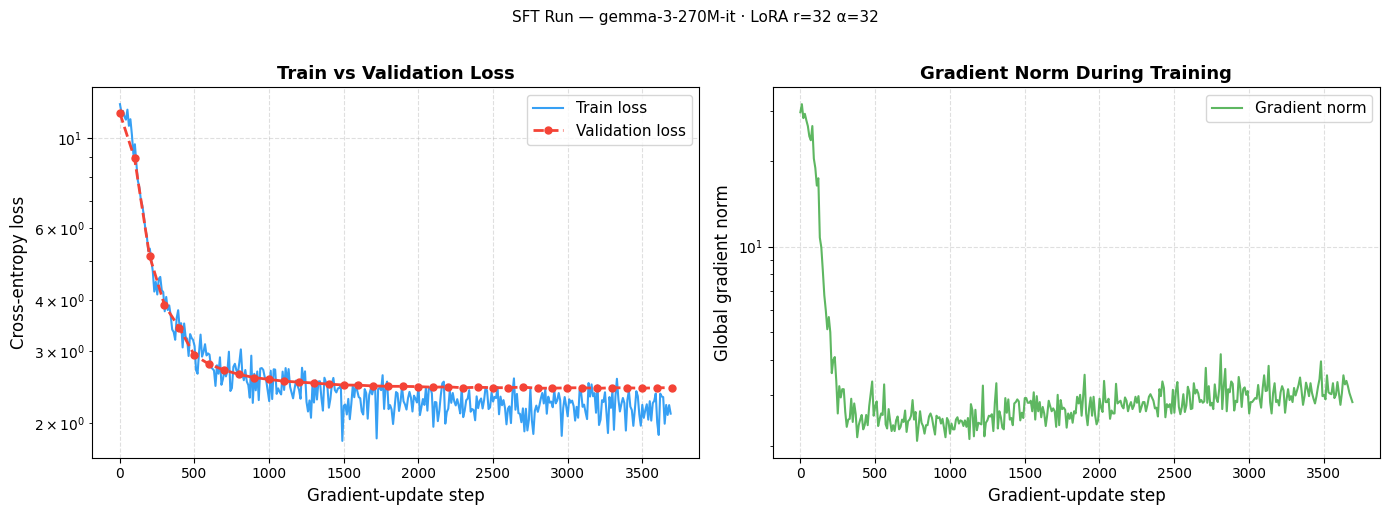

Figure saved → training_curves.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

train_steps, train_losses = (
    zip(*hook.train_loss_history) if hook.train_loss_history else ([], [])
)
eval_steps, eval_losses = (
    zip(*hook.eval_loss_history) if hook.eval_loss_history else ([], [])
)
gn_steps, gn_vals = zip(*hook.grad_norm_history) if hook.grad_norm_history else ([], [])

has_grad_norm = len(gn_steps) > 0
n_panels = 2 if has_grad_norm else 1

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

# ── Panel 1 · Loss ────────────────────────────────────────────────────────────
train_steps_ds, train_losses_ds = downsample(train_steps, train_losses, k=10)
eval_steps_ds, eval_losses_ds = downsample(eval_steps, eval_losses, k=1)  # keep eval dense

ax = axes[0]
if train_losses:
    ax.plot(
        train_steps_ds,
        train_losses_ds,
        label="Train loss",
        color="#2196F3",
        lw=1.5,
        alpha=0.9,
    )
if eval_losses:
    ax.plot(
        eval_steps_ds,
        eval_losses_ds,
        label="Validation loss",
        color="#F44336",
        lw=2,
        linestyle="--",
        marker="o",
        markersize=5,
    )

ax.set_xlabel("Gradient-update step", fontsize=12)
ax.set_ylabel("Cross-entropy loss", fontsize=12)
ax.set_title("Train vs Validation Loss", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ── Panel 2 · Gradient Norm (if available) ───────────────────────────────────
if has_grad_norm:
    gn_steps_ds, gn_vals_ds = downsample(gn_steps, gn_vals, k=10)
    ax2 = axes[1]
    ax2.plot(
        gn_steps_ds, gn_vals_ds, color="#4CAF50", lw=1.5, alpha=0.9, label="Gradient norm"
    )
    ax2.set_xlabel("Gradient-update step", fontsize=12)
    ax2.set_ylabel("Global gradient norm", fontsize=12)
    ax2.set_title("Gradient Norm During Training", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.set_yscale("log")
    ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
else:
    print(
        "ℹ️  Gradient norm was not exposed by the tunix training context "
        "(hook.grad_norm_history is empty).\n"
        "   The right panel has been omitted. To enable it, ensure your "
        "tunix version sets train_ctx.grad_norm during the training step."
    )

plt.suptitle(
    f"SFT Run — {params.MODEL_KEY} · LoRA r={params.LORA_RANK} α={params.LORA_ALPHA}",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → training_curves.png")

## 8 · Upload to Hugging Face Hub

In [17]:
from huggingface_hub import HfApi

api = HfApi()
token = os.environ.get("HF_TOKEN")
print(f"Pushing to {params.TUNED_MODEL_NAME} ...")
try:
    api.create_repo(
        repo_id=params.TUNED_MODEL_NAME,
        repo_type="model",
        private=False,
        exist_ok=True,
        token=token,
    )
    api.upload_file(
        path_or_fileobj=os.path.join(params.OUTPUT_DIR, "adapter_model.safetensors"),
        path_in_repo="adapter_model.safetensors",
        repo_id=params.TUNED_MODEL_NAME,
        token=token,
    )
    api.upload_file(
        path_or_fileobj=os.path.join(params.OUTPUT_DIR, "adapter_config.json"),
        path_in_repo="adapter_config.json",
        repo_id=params.TUNED_MODEL_NAME,
        token=token,
    )
    print(f"Successfully pushed to https://huggingface.co/{params.TUNED_MODEL_NAME}")
except Exception as e:
    print(f"Error pushing to Hub: {e}")

Pushing to lmassaron/gemma-3-270M-it-medical-cardiology-lora ...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Successfully pushed to https://huggingface.co/lmassaron/gemma-3-270M-it-medical-cardiology-lora
